# Module 9 — Communicating Results to a Product/Business Audience

Part of the **A/B Testing Playbook** learning program. Full program context, progress tracker, and how this module fits with the rest: see `CURRICULUM.md`.

## From the curriculum

> **Concepts**
> - Translating statistical results into a ship/no-ship recommendation
> - Framing uncertainty and effect size for non-technical stakeholders
> - Handling an inconclusive or flat result without it reading as failure
> - Pushing back on stakeholders who want to peek early or ignore guardrails (directly using Modules 5 and 6)
>
> **Why it matters**
> This is the one area where your existing B2B background transfers most directly — stakeholder communication is stakeholder communication. This module mainly adapts it to experimentation-specific framing.
>
> **Worked example**
> Bad summary: *"p = 0.03, we're good to ship!"* — no effect size, no business context, implies false certainty. Better summary: *"Checkout completion rose from 22% to 23.4% (a 1.4pp / ~6% relative lift, 95% CI: 0.5pp-2.3pp). Guardrails (revenue per user, refund rate) are flat. We recommend shipping — the effect is both statistically and practically meaningful, and downside risk looks low."* Same underlying result, one version a PM can actually act on.
>
> **Resources** — none needed; this module leans on your existing strengths, just retargeted.
>
> **Exercise type:** written recommendation memos based on Module 6 results, evaluated for clarity and honesty about uncertainty.
>
> **Interview angle:** "walk me through how you'd present this result to a PM who wants to ship anyway."

## Lesson

### Translating statistics into a recommendation

A good memo always has the same four pieces, in order: **the number** (effect size, in real business units — not just a p-value), **the uncertainty** (a CI, in the same units), **the guardrails** (did anything else move that shouldn't have), and **a recommendation** (ship / don't ship / need more data — stated plainly, not left for the reader to infer). Skipping any piece is where most bad memos go wrong — usually by skipping straight from a p-value to a recommendation, with no effect size in between.

### Framing uncertainty for non-technical stakeholders

Nobody outside analytics wants to hear "the 95% CI is (0.02pp, 0.22pp)." They want to hear what that CI *means*: is the effect definitely real but small, or could it plausibly be huge, or could it plausibly be nothing? Translate the CI's width into a plain sentence before showing the number, not instead of it — the number stays for anyone who wants to check it themselves.

### Handling an inconclusive result

An inconclusive test didn't fail — Module 6 already established that a wide CI is information, not a null result. The memo-writing version of that lesson: never write "the test showed no effect." Write what's actually true — "we can't yet distinguish a meaningful effect from noise at this sample size" — and follow it with an actual next step (run longer, or accept the ambiguity and move on), not a shrug.

### Pushing back on stakeholders

Two pushback moments come up constantly: someone wants to call the test early because it's already significant (Module 5's peeking problem), or someone wants to ship despite a guardrail dip ("it's probably nothing"). Both need the same move: **explain the specific mechanism of the risk in one sentence, then offer the safe alternative** — not just "no." Part 4 below scripts both.

### Part 0 — Regenerating the results to write about

Reusing Module 6's exact results (same seeds, same code) rather than retyping numbers from memory — these memos are about *communicating* real results, not generating new ones.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GOOD = "#1a7f37"
BAD = "#cf222e"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

def z_test_pvalue(x1, n1, x2, n2):
    p1, p2 = x1 / n1, x2 / n2
    p_pooled = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n1 + 1 / n2))
    return 2 * (1 - stats.norm.cdf(abs((p2 - p1) / se)))

def ci95_diff(x1, n1, x2, n2):
    p1, p2 = x1 / n1, x2 / n2
    se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    diff = p2 - p1
    z = stats.norm.ppf(0.975)
    return diff - z * se, diff + z * se

# Test A: huge n, tiny true effect (Module 6, seed 7)
rng_a = np.random.default_rng(7)
n_a = 400_000
c_a = rng_a.binomial(n_a, 0.0500)
t_a = rng_a.binomial(n_a, 0.0515)
p_a = z_test_pvalue(c_a, n_a, t_a, n_a)
lo_a, hi_a = ci95_diff(c_a, n_a, t_a, n_a)

# Test B: small n, large true effect (Module 6, seed 2)
rng_b = np.random.default_rng(2)
n_b = 200
c_b = rng_b.binomial(n_b, 0.05)
t_b = rng_b.binomial(n_b, 0.09)
p_b = z_test_pvalue(c_b, n_b, t_b, n_b)
lo_b, hi_b = ci95_diff(c_b, n_b, t_b, n_b)

print(f"Test A: lift {(t_a-c_a)/n_a*100:+.2f}pp, CI ({lo_a*100:+.2f}, {hi_a*100:+.2f})pp, p={p_a:.3f}")
print(f"Test B: lift {(t_b-c_b)/n_b*100:+.1f}pp, CI ({lo_b*100:+.2f}, {hi_b*100:+.2f})pp, p={p_b:.3f}")

Test A: lift +0.12pp, CI (+0.02, +0.22)pp, p=0.015
Test B: lift +4.0pp, CI (-0.64, +8.64)pp, p=0.092


### Part 1 — Memo for Test A: statistically significant, practically trivial

The trap: a clean p < 0.05 tempts a one-line "ship it" memo. The effect size tells a different story.

<span style="color:#cf222e"><b>Bad memo</b></span>:

> Subject: Checkout test results — ship recommendation
>
> The checkout test hit significance (p = 0.015). Recommend shipping.

**What's wrong with it:** no effect size, no sense of scale, no guardrail mention. A PM reading this has no way to tell this apart from a genuinely large win — the memo is technically true and practically useless.

---

<span style="color:#1a7f37"><b>Good memo</b></span>:

> Subject: Checkout test results — recommend holding, not shipping
>
> Checkout completion rose from 5.00% to 5.11% (a +0.12pp / ~2% relative lift, 95% CI: +0.02pp to +0.22pp, p = 0.015). The effect is real — the CI doesn't cross zero — but it's small: at our volume, that's a detectable difference, not necessarily a meaningful one.
>
> **Recommendation: hold.** Before shipping, weigh the effect size against the change's engineering/maintenance cost and any guardrail risk — a statistically real but this-small a lift may not clear the bar on its own. This is a business call on the number, not a statistical one.

**Why it's better:** same underlying result, but now the reader can actually judge whether "real but tiny" is worth shipping — which was never a question statistics alone could answer.

### Part 2 — Memo for Test B: an inconclusive result

The trap here is the opposite one: writing this off as "the test failed" when it's genuinely still an open question.

<span style="color:#cf222e"><b>Bad memo</b></span>:

> Subject: Homepage test results — no effect found
>
> The test did not reach significance (p = 0.092). The change does not work. Recommend abandoning this direction.

**What's wrong with it:** flatly false. The CI runs from −0.6pp to +8.6pp — a huge real win is still entirely consistent with this data. "Did not reach significance" got silently translated into "doesn't work," which the data never said.

---

<span style="color:#1a7f37"><b>Good memo</b></span>:

> Subject: Homepage test results — inconclusive, recommend a follow-up
>
> Observed lift: +4.0pp (95% CI: −0.6pp to +8.6pp, p = 0.092). This is genuinely inconclusive, not a null result — the data is consistent with anything from a small loss to a very large win.
>
> Reliably detecting an effect this size would need about 635 users per arm (Module 3's sample-size math); we ran 200. **Recommendation: this is worth a proper follow-up at the larger sample size before deciding either way** — the current data doesn't support "ship" or "abandon," only "not enough evidence yet."

**Why it's better:** gives the reader the actual decision — is a bigger follow-up test worth the cost — instead of a false closure that quietly kills a potentially good idea.

### Part 3 — Memo for the segment table (Module 6): a mixed result

The trap: an overall null result sitting next to one credible finding and one statistical trap, in the same table.

<span style="color:#cf222e"><b>Bad memo</b></span> (version 1 — takes the aggregate at face value):

> Subject: Onboarding test — no significant effect, closing out
>
> Overall result was flat (p = 0.74). No action needed.

**What's wrong:** ignores that "New users" — the one segment the hypothesis actually predicted — showed a real, credible effect. Closing out here throws away a genuine finding.

<span style="color:#cf222e"><b>Bad memo</b></span> (version 2 — chases the flashy segment):

> Subject: Onboarding test — Desktop users hurt, recommend blocking rollout there
>
> Desktop showed a significant −1.4pp drop (p = 0.04). Recommend excluding Desktop from the rollout.

**What's wrong:** this is Module 6/7's trap exactly — an unplanned, mechanism-free segment result among 8 cuts tested, most likely noise. Acting on it delays a good change and burns engineering time chasing a phantom bug.

---

<span style="color:#1a7f37"><b>Good memo</b></span>:

> Subject: Onboarding test — recommend a scoped follow-up for new users
>
> Overall result was flat (p = 0.74). One segment, New users, showed a real lift (+1.57pp, p = 0.008) — and it's the segment the original hypothesis specifically predicted (only new users see this onboarding screen). Desktop also showed a significant result (−1.4pp, p = 0.04), but with no mechanism connecting device type to this change and 8 segments tested, this is very plausibly noise (Module 5/7).
>
> **Recommendation: run a dedicated follow-up test scoped to new users** to confirm the finding before shipping broadly. Do not act on the Desktop result without independent evidence it's real.

**Why it's better:** treats the credible and non-credible findings differently, on stated criteria, instead of either ignoring everything or reacting to whichever number looks most dramatic.

### Part 4 — Pushback scripts

Two conversations that come up constantly. The move both times: name the specific mechanism in one sentence, then offer the safe alternative — not just "no."

**"It's already significant on day 2, can we call it and ship?"**

> Not yet — checking a test repeatedly and stopping the moment it crosses significance inflates the false-positive rate well past 5% (Module 5), so "significant on day 2" isn't as trustworthy as it looks. We pre-committed to [N] days for a reason: that's what keeps this number meaningful. I can give you a directional read now, off the record, but the real decision needs the full run.

**"The refund-rate guardrail ticked up slightly, but it's probably nothing — can we ship anyway?"**

> Maybe, but "probably nothing" is exactly the judgment call guardrails exist to take out of our hands. Let me check whether that tick is within normal noise or an actual signal — if it's noise, I'll confirm that with the guardrail's own confidence interval and we ship with an actual answer instead of a hunch, and if it's real, we've caught it before it shipped.

### Part 5 — A stakeholder-ready summary chart

The technical version of these results (Module 6's raw density-comparison chart) isn't what a PM needs. This is: one line per test, the effect size as a dot, uncertainty as a bar, a zero-effect reference line — readable in five seconds.

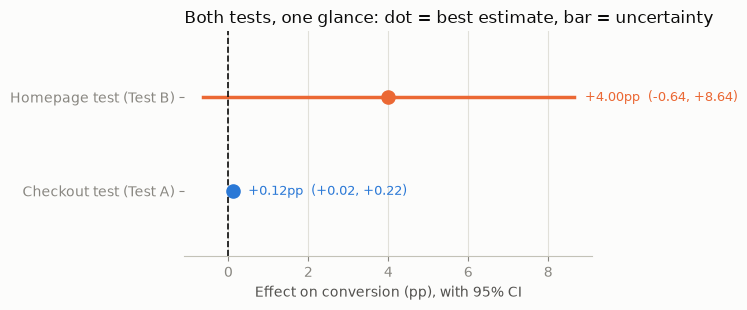

In [2]:
fig, ax = plt.subplots(figsize=(7.5, 3.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

tests = [
    ("Checkout test (Test A)", (t_a - c_a) / n_a * 100, lo_a * 100, hi_a * 100, BLUE),
    ("Homepage test (Test B)", (t_b - c_b) / n_b * 100, lo_b * 100, hi_b * 100, ORANGE),
]

for i, (label, mean, lo, hi, color) in enumerate(tests):
    ax.plot([lo, hi], [i, i], color=color, linewidth=2.5)
    ax.scatter([mean], [i], color=color, s=90, zorder=5)
    ax.annotate(f"{mean:+.2f}pp  ({lo:+.2f}, {hi:+.2f})", xy=(hi, i), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=9, color=color)

ax.axvline(0, color=INK, linewidth=1.2, linestyle="--")
ax.set_yticks(range(len(tests)))
ax.set_yticklabels([t[0] for t in tests], color=INK)
ax.set_xlabel("Effect on conversion (pp), with 95% CI", color=INK_SECONDARY)
ax.set_title("Both tests, one glance: dot = best estimate, bar = uncertainty", color=INK, fontsize=12, loc="left")
ax.set_ylim(-0.7, len(tests) - 0.3)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)
ax.xaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**What this shows:** the checkout test's bar is short and sits entirely right of zero — small but real. The homepage test's bar is long and crosses zero — could be a big win, could be nothing. Same visual language conveys both "how big" and "how sure" without a single p-value on the chart — exactly what a five-second stakeholder read needs, with the full numbers available alongside for anyone who wants them.

**The rule this relies on:** a bar is significant exactly when `|lift| > 1.96 x SE` (it doesn't touch zero), and not significant when `|lift| <= 1.96 x SE` (it touches or crosses zero) — the same 1.96 used to build the 95% CI in the first place.

## Key takeaways

- Every memo needs four things in order: effect size in business units, uncertainty (CI), guardrail status, and a stated recommendation — skipping the effect size is the single most common failure
- "Not significant" is never "doesn't work" — write what's actually true (inconclusive at this sample size) and give a next step, not a shrug
- When a result set is mixed (a credible finding next to a statistical trap), treat them differently on stated criteria — don't average them into one verdict or chase whichever number is most dramatic
- Pushback on peeking or ignoring guardrails works best as "here's the specific mechanism, here's the safe alternative" — not a bare no
- This module leans on skills you already have; the only new part is experimentation-specific vocabulary (CI, guardrail, significance) translated into plain business language

---
*Status: mark this module's row in `CURRICULUM.md`'s progress table once reviewed.*